# 07 - Entraînement du modèle de Machine Learning

## Objectif

Ce notebook a pour objectif d'entraîner des modèles de Machine Learning afin de prédire la direction future du marché.

Les variables utilisées proviennent de quatre approches complémentaires :

- Analyse statistique
- Clustering
- Détection de patterns Smart Money Concepts (SMC)
- Machine Learning

Les modèles testés sont :

- Random Forest
- XGBoost

In [18]:
#Importer les bibliothèques

In [19]:
from pathlib import Path
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# 3. Chargement des données enrichies

Chargement des données contenant les indicateurs techniques,
les clusters et les patterns SMC.

In [25]:
PROJECT_ROOT = Path.cwd().parent

PATTERN_DIR = PROJECT_ROOT / "data" / "patterns"

gold = pd.read_csv(
    PATTERN_DIR / "gold_patterns.csv"
)

print("Gold :", gold.shape)

display(gold.head())

Gold : (11403, 35)


,Datetime,Close,High,Low,Open,Volume,Ticker,EMA20,EMA50,RSI,...,Swing_High,Swing_Low,Last_Swing_High,Last_Swing_Low,BOS_Bullish,BOS_Bearish,CHOCH_Bullish,CHOCH_Bearish,FVG_Bullish,FVG_Bearish
0,2024-05-31 01:00:00+00:00,2367.899902,2368.800049,2344.800049,2367.500000,3302,GC=F,2363.060853,2360.692465,57.070461,...,0,0,NaN,NaN,0,0,0,0,0,0
1,2024-05-31 02:00:00+00:00,2363.899902,2369.000000,2342.000000,2367.800049,2571,GC=F,2363.150699,2360.907379,58.701180,...,0,0,NaN,NaN,0,0,0,0,0,0
2,2024-05-31 03:00:00+00:00,2364.100098,2364.699951,2338.800049,2363.800049,5985,GC=F,2363.251172,2361.115523,51.963800,...,0,0,NaN,NaN,0,0,0,0,0,0
3,2024-05-31 04:00:00+00:00,2365.100098,2366.899902,2342.899902,2364.800049,3149,GC=F,2363.444790,2361.368713,40.225781,...,0,0,NaN,NaN,0,0,0,0,0,0
4,2024-05-31 05:00:00+00:00,2363.500000,2365.600098,2341.000000,2365.000000,2597,GC=F,2363.450517,2361.500924,45.726567,...,0,0,NaN,NaN,0,0,0,0,0,0


In [26]:
PROJECT_ROOT = Path.cwd().parent

PATTERN_DIR = PROJECT_ROOT / "data" / "patterns"

silver = pd.read_csv(
    PATTERN_DIR / "silver_patterns.csv"
)

print("Silver :", silver.shape)

display(silver.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\FORMATION_CONTINUE_AND_TRAINING_SKILLS\\420_A62_BB PROJET_DE_SYNTHESE\\ai-trading-project\\data\\patterns\\silver_patterns.csv'

# 4. Vérification des colonnes

Vérification de la présence des variables nécessaires à l'entraînement du modèle.

In [22]:
print(gold.columns.tolist())


['Datetime', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'EMA20', 'EMA50', 'RSI', 'ATR', 'Target', 'EMA200', 'Return', 'Volatility', 'Market_Regime', 'Hour', 'DayOfWeek', 'Timeframe', 'Cluster', 'Previous_High', 'BOS', 'Previous_Low', 'CHOCH', 'FVG', 'Swing_High', 'Swing_Low', 'Last_Swing_High', 'Last_Swing_Low', 'BOS_Bullish', 'BOS_Bearish', 'CHOCH_Bullish', 'CHOCH_Bearish', 'FVG_Bullish', 'FVG_Bearish']


# 5. Vérification des valeurs manquantes

Les indicateurs comme RSI et ATR génèrent naturellement des valeurs manquantes au début de la série temporelle.

In [23]:
gold[["EMA20","EMA50","EMA200","RSI","ATR"]].isna().sum()

EMA20     0
EMA50     0
EMA200    0
RSI       0
ATR       0
dtype: int64

# 6. Sélection des variables explicatives et de la cible

Les variables explicatives sont les indicateurs techniques.
La cible représente la direction future du marché.

In [24]:
statistical_features = [
    "EMA20",
    "EMA50",
    "EMA200",
    "RSI",
    "ATR",
    "Return",
    "Volatility",
    "Hour",
    "DayOfWeek"
]

X = gold[statistical_features]
y = gold["Target"]

print("X :", X.shape)
print("y :", y.shape)

X : (11403, 9)
y : (11403,)


# 7. Nettoyage final du jeu d'entraînement

Suppression des lignes contenant des valeurs manquantes avant l'entraînement du modèle.

In [35]:
dataset = pd.concat([X, y], axis=1)
dataset = dataset.dropna()

X = dataset[statistical_features]
y = dataset["Target"]

print("Dataset final :", dataset.shape)

Dataset final : (11403, 10)


# 8. Vérification de la distribution de la cible

Cette étape permet de vérifier si les classes Achat/Vente sont équilibrées.

In [36]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Target
1    6134
0    5269
Name: count, dtype: int64
Target
1    53.792862
0    46.207138
Name: proportion, dtype: float64


# 9. Séparation des données Train/Test

Le jeu de données est séparé en données d'entraînement et données de test.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (9122, 9)
Test : (2281, 9)


# PARTIE A — RANDOM FOREST

# 10. Entraînement du modèle Random Forest

Random Forest est utilisé comme premier modèle MVP pour le prototype.

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_model.fit(
    X_train,
    y_train)

print("Modèle entraîné avec succès")

Modèle entraîné avec succès


# 11. Prédictions

Le modèle est utilisé pour prédire les signaux sur les données de test.

In [39]:
rf_predictions = rf_model.predict(
    X_test
)

print(
    rf_predictions[:20]
)

[1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0]


# 12. Évaluation du modèle Random Forest

Évaluation du modèle à l'aide de métriques de classification.

In [43]:
rf_accuracy = accuracy_score(y_test,rf_predictions)
print("Accuracy :",rf_accuracy)

print(classification_report(y_test, rf_predictions))

Accuracy : 0.7632617273125822
              precision    recall  f1-score   support

           0       0.76      0.71      0.74      1054
           1       0.77      0.81      0.79      1227

    accuracy                           0.76      2281
   macro avg       0.76      0.76      0.76      2281
weighted avg       0.76      0.76      0.76      2281



# 13. Matrice de confusion Random Forest

La matrice de confusion permet de visualiser les bonnes et mauvaises prédictions.

Text(0.5, 1.0, 'Matrice de confusion - Random Forest')

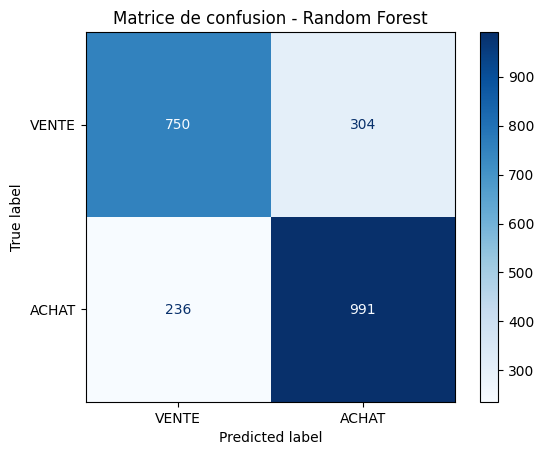

In [44]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["VENTE","ACHAT"]
)

disp.plot(cmap="Blues")

plt.title(
    "Matrice de confusion - Random Forest"
)


# PARTIE B — XGBOOST

# 14. Entraînement du modèle XGBoost

Le modèle XGBoost est utilisé afin de comparer ses performances avec celles du modèle Random Forest.

In [45]:
#pip install xgboost


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("Accuracy XGBoost :", accuracy_score(y_test, xgb_predictions))
print(classification_report(y_test, xgb_predictions))

Accuracy XGBoost : 0.5918456817185445
              precision    recall  f1-score   support

           0       0.63      0.29      0.40      1054
           1       0.58      0.85      0.69      1227

    accuracy                           0.59      2281
   macro avg       0.60      0.57      0.54      2281
weighted avg       0.60      0.59      0.56      2281



# 15. Prédictions XGBoost

Le modèle est utilisé pour prédire les signaux sur les données de test.

In [47]:
xgb_predictions = xgb_model.predict(
    X_test
)

print(
    xgb_predictions[:20]
)

[1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1]


# 16. Évaluation du modèle XGBoost

In [48]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(
    "Accuracy :",
    xgb_accuracy
)

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

Accuracy : 0.5918456817185445
              precision    recall  f1-score   support

           0       0.63      0.29      0.40      1054
           1       0.58      0.85      0.69      1227

    accuracy                           0.59      2281
   macro avg       0.60      0.57      0.54      2281
weighted avg       0.60      0.59      0.56      2281



# 17. Matrice de confusion XGBoost

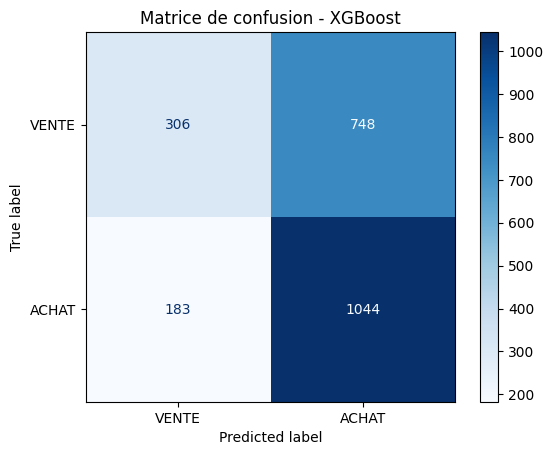

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

xgb_cm = confusion_matrix(y_test, xgb_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["VENTE", "ACHAT"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - XGBoost")
plt.show()

# 18. Comparaison des modèles

In [50]:
comparaison = pd.DataFrame({

    "Modèle":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy
    ]
})

display(comparaison)

,Modèle,Accuracy
0,Random Forest,0.763262
1,XGBoost,0.591846


# 19. Sélection du meilleur modèle

In [51]:
if rf_accuracy > xgb_accuracy:

    best_model = rf_model
    best_name = "Random Forest"

else:

    best_model = xgb_model
    best_name = "XGBoost"

print(
    "Meilleur modèle :",
    best_name
)

Meilleur modèle : Random Forest


# 20. Sauvegarde des modèles

In [53]:
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(
    exist_ok=True
)

joblib.dump(
    rf_model,
    MODELS_DIR / "gold_random_forest.pkl"
)

joblib.dump(
    xgb_model,
    MODELS_DIR / "gold_xgboost.pkl"
)

print(
    "Modèles sauvegardés"
)

Modèles sauvegardés


# 21. Conclusion

Deux modèles de Machine Learning ont été entraînés :

- Random Forest
- XGBoost

Leurs performances ont été évaluées et comparées à l'aide des métriques :

- Accuracy
- Precision
- Recall
- F1-score
- Matrice de confusion

Le meilleur modèle sera utilisé dans les prochaines étapes du projet :

- Backtesting
- Dashboard
- Déploiement
- Mise en production